In this project, our goal is to build a model that can estimate the quality of wine using its chemical properties. We will work with the open-source Wine Quality dataset, which includes key attributes influencing wine characteristics. By applying different machine learning algorithms, we aim to predict the quality scores assigned to the wine samples.



Importing Libraries and Dataset:
- Pandas: essential for managing and manipulating tabular data efficiently.
- NumPy: provides powerful tools for numerical operations and handling arrays.
- Matplotlib & Seaborn: widely used libraries to create visualizations and better understand data patterns.
- Scikit-learn (sklearn): offers a collection of ready-to-use functions for preprocessing, building machine learning models, and evaluating their performance.
- XGBoost: an advanced boosting algorithm designed to deliver high prediction accuracy and often used in competitive machine learning tasks.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=";")
print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


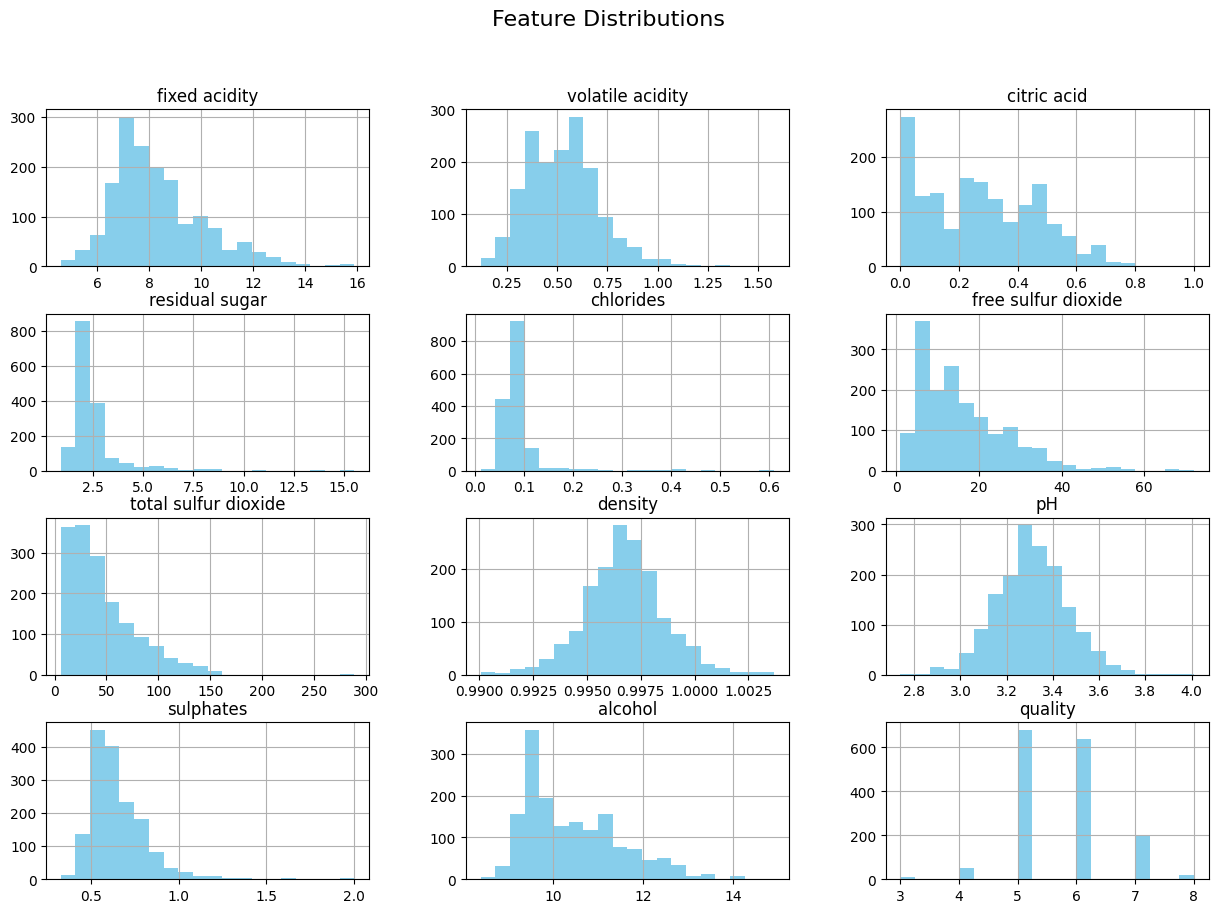

In [6]:
df.hist(figsize=(15,10), bins=20, color="skyblue")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


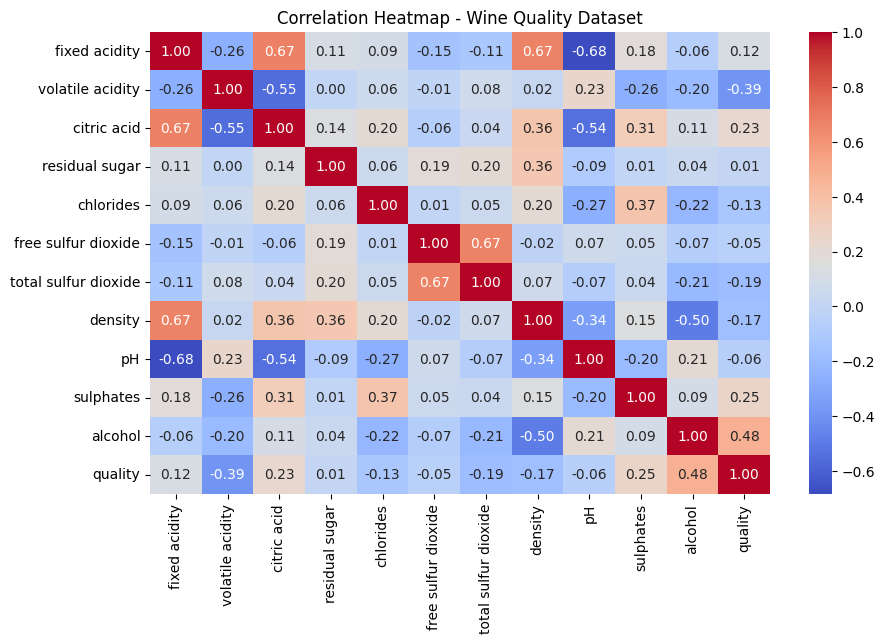

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [7]:
corr = df.corr()

# رسم Heatmap
plt.figure(figsize=(10,6))
sb.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Wine Quality Dataset")
plt.show()

# نشوف أقوى علاقات مع quality
print(corr['quality'].sort_values(ascending=False))

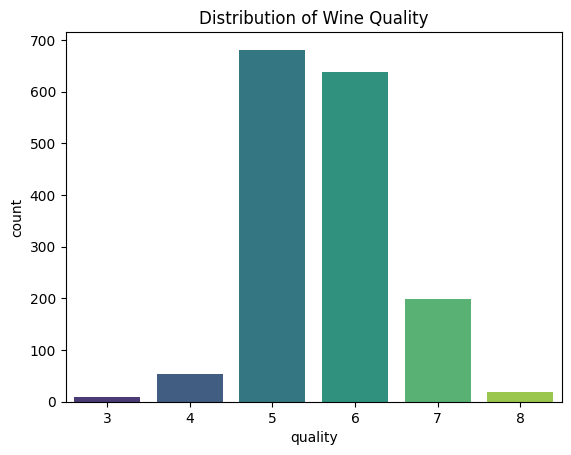

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['quality'], palette="viridis")
plt.title("Distribution of Wine Quality")
plt.show()


In [11]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)
X = df.drop(['quality', 'quality_label'], axis=1)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# لو محتاج تحافظ على الداتا كاملة:
df_scaled = pd.concat([X_scaled, df[['quality', 'quality_label']].reset_index(drop=True)], axis=1)


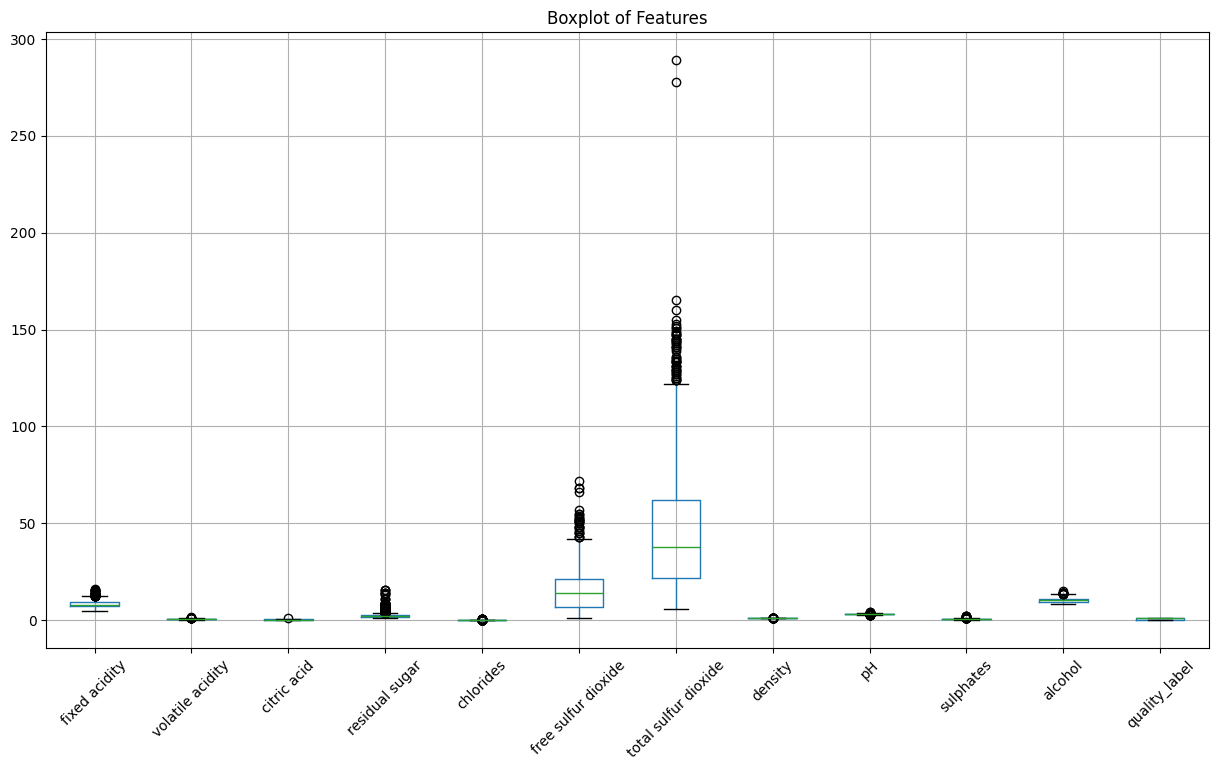

In [12]:
plt.figure(figsize=(15,8))
df.drop('quality', axis=1).boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()


In [14]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('quality')  # أو 'quality_label' لو موجود
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # كابينج: استبدال القيم الشاذة بالحدود
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])


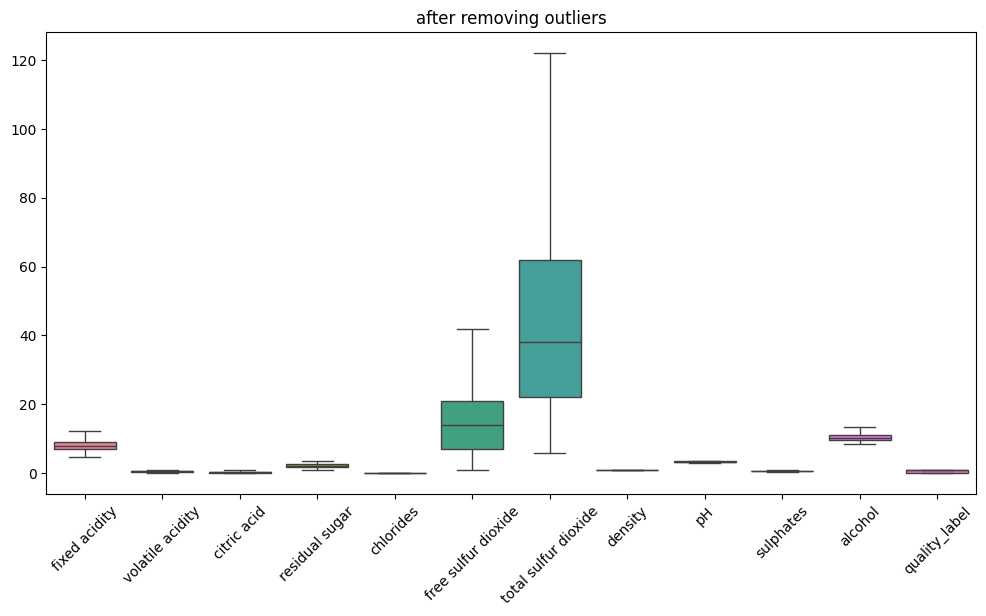

In [15]:
plt.figure(figsize=(12,6))
sb.boxplot(data=df[num_cols])
plt.title("after removing outliers")

plt.xticks(rotation=45)
plt.show()

In [16]:
class_dist = df['quality'].value_counts().sort_index()
percent_dist = df['quality'].value_counts(normalize=True).sort_index() * 100

# عرض النتائج
print("🔹 عدد العينات في كل فئة:")
print(class_dist)
print("\n🔹 النسبة المئوية لكل فئة:")
print(percent_dist.round(2))

🔹 عدد العينات في كل فئة:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

🔹 النسبة المئوية لكل فئة:
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


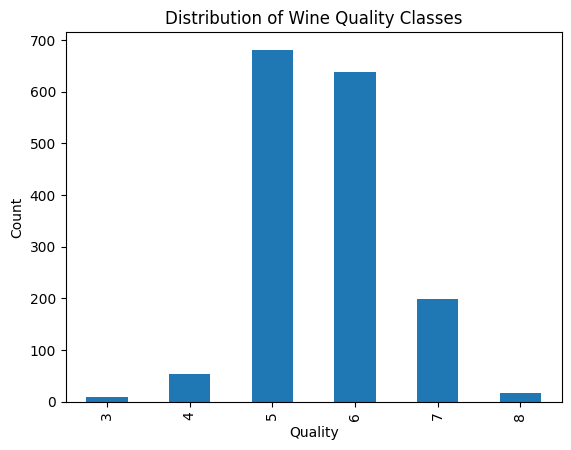

In [17]:
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality Classes")
plt.show()


In [20]:
#
# 2️⃣ فصل المميزات (X) عن الهدف (y)
from imblearn.over_sampling import SMOTE
X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

# 3️⃣ تقسيم البيانات لتدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4️⃣ تطبيق SMOTE على بيانات التدريب فقط
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# 5️⃣ طباعة النتائج قبل وبعد
print("🔹 قبل تطبيق SMOTE:")
print(y_train.value_counts())

print("\n🔹 بعد تطبيق SMOTE:")
print(y_res.value_counts())

🔹 قبل تطبيق SMOTE:
quality_label
1.0    676
0.0    603
Name: count, dtype: int64

🔹 بعد تطبيق SMOTE:
quality_label
1.0    676
0.0    676
Name: count, dtype: int64


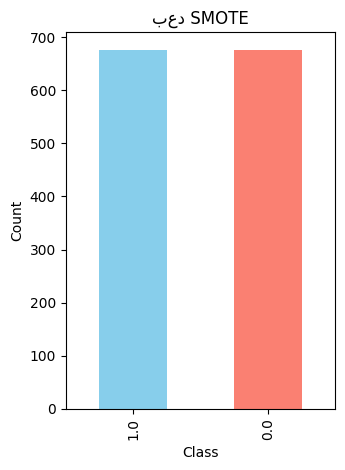

In [21]:
plt.subplot(1,2,2)
y_res.value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title("بعد SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [22]:
%pip install catboost

In [23]:

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "SVM": SVC(),
    "Neural Net (MLP)": MLPClassifier(max_iter=1000),
    "XGBoost": XGBClassifier(eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

# ---------------------------
# 🔹 تجربة كل الموديلات
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append((name, acc, f1))

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print(classification_report(y_test, y_pred))

# ---------------------------
# 📊 عرض النتائج مجمعة
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
print("\n\n📊 Summary of All Models:\n")
print(results_df.sort_values(by="Accuracy", ascending=False))



Logistic Regression
Accuracy: 0.759375
F1 Score: 0.7768115942028986
              precision    recall  f1-score   support

         0.0       0.71      0.77      0.74       141
         1.0       0.81      0.75      0.78       179

    accuracy                           0.76       320
   macro avg       0.76      0.76      0.76       320
weighted avg       0.76      0.76      0.76       320


KNN
Accuracy: 0.60625
F1 Score: 0.6440677966101694
              precision    recall  f1-score   support

         0.0       0.55      0.57      0.56       141
         1.0       0.65      0.64      0.64       179

    accuracy                           0.61       320
   macro avg       0.60      0.60      0.60       320
weighted avg       0.61      0.61      0.61       320


Decision Tree
Accuracy: 0.746875
F1 Score: 0.7705382436260623
              precision    recall  f1-score   support

         0.0       0.71      0.73      0.72       141
         1.0       0.78      0.76      0.77       179

In [24]:
best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]
print("\n🔥 Best Model:")
print(best_model)



🔥 Best Model:
Model       Extra Trees
Accuracy       0.821875
F1 Score       0.840336
Name: 4, dtype: object


In [26]:
import pickle

best_model_name = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]['Model']
best_model = models[best_model_name]

with open('wine_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [27]:
import pickle
from sklearn.preprocessing import MinMaxScaler

# بعد تدريب Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
